#  Stock Price Prediction Using Machine Learning
This project aims to predict the next day's stock closing price using historical data from Indian markets. We use TCS stock data and apply a simple linear regression model.


## Overview of Stock Price Prediction

Stock price prediction is the process of determining the future value of a company's stock or other financial instrument traded on an exchange. The idea is to use historical price patterns and other indicators to forecast upcoming price trends. In this project, we focus on predicting the next day’s closing price using machine learning—specifically, a Linear Regression model.

We utilize the `yfinance` package to fetch historical stock data, perform basic data analysis, engineer useful features, and finally train a regression model on the data.


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import joblib
import os


## Load Stock Data
<b>Source:</b> Data is fetched using the yfinance library, which allows downloading stock data from Yahoo Finance.<br><br>
<b>Ticker used:</b> Typically a stock symbol like "TCS.NS" is used.<br><br>
<b>Period:</b> Historical prices over a specified time frame.

The `yfinance` library provides OHLCV data:
- **Open/Close**: Day's starting/ending price
- **High/Low**: Maximum/minimum price during trading
- **Volume**: Number of shares traded
Closing price is typically used as the prediction target, while other features capture market dynamics.

In [3]:
# Load data from Yahoo Finance
ticker = "TCS.NS"  # TCS on NSE
period='1y'
interval='1d'
def download_stock_data(ticker: str, period: str = "1y", interval: str = "1d") -> pd.DataFrame:
    df = yf.download(ticker, period=period, interval=interval)
    df.reset_index(inplace=True)
    return df

df = download_stock_data(ticker, period, interval)


C:\Users\lc\AppData\Local\Temp\ipykernel_10164\1793022259.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, interval=interval)
[*********************100%***********************]  1 of 1 completed



# Data Overview

## Exploratory Data Analysis (EDA)
EDA reveals data distributions, trends, and anomalies:
- **Summary statistics** identify central tendencies and dispersion
- **Visualizations** show price movements and volatility
- **Time-series decomposition** highlights trends and seasonality
This informs feature engineering and model selection.

In [4]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
0,2024-07-01,3915.110840,3938.238160,3822.404778,3822.404778,2658723
1,2024-07-02,3953.688965,3959.593812,3919.391786,3930.266595,2307449
2,2024-07-03,3902.365967,3962.251056,3892.278519,3956.247699,1821198
3,2024-07-04,3957.183105,3983.164581,3918.949358,3936.417867,2518001
4,2024-07-05,3948.178223,3962.891087,3924.755611,3946.406720,1668616


In [5]:
df.columns.to_list()

[('Date', ''),
 ('Close', 'TCS.NS'),
 ('High', 'TCS.NS'),
 ('Low', 'TCS.NS'),
 ('Open', 'TCS.NS'),
 ('Volume', 'TCS.NS')]

### Columns:

- Open: Opening price of the stock.

- High: Highest price of the day.

- Low: Lowest price of the day.

- Close: Closing price (often used for prediction).

- Adj Close: Adjusted for splits/dividends.

- Volume: Number of shares traded.

## Summary Statistics

In [6]:
df.describe()

Price,Date,Close,High,Low,Open,Volume
Ticker,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
count,249,249.000000,249.000000,249.000000,249.000000,2.490000e+02
mean,2024-12-28 13:58:33.253011968,3920.867972,3959.994863,3886.346540,3922.436556,2.440958e+06
min,2024-07-01 00:00:00,3203.030273,3241.191062,3029.126153,3072.688904,0.000000e+00
25%,2024-09-27 00:00:00,3512.727539,3538.000000,3477.689218,3512.777147,1.681975e+06
50%,2024-12-30 00:00:00,4039.038818,4087.837733,4005.448161,4044.329012,2.133641e+06
75%,2025-03-27 00:00:00,4216.729004,4249.017605,4180.194706,4212.430629,2.845192e+06
max,2025-06-30 00:00:00,4491.941895,4529.919334,4450.758575,4513.889903,1.350916e+07
std,NaN,370.141251,374.537803,368.297105,371.427129,1.343907e+06


### This provides:

- Central tendency (mean, 50%)

- Spread (min, max)

- Range of values over years



## Missing Values Check

In [7]:
df.isnull().sum()

Price   Ticker
Date              0
Close   TCS.NS    0
High    TCS.NS    0
Low     TCS.NS    0
Open    TCS.NS    0
Volume  TCS.NS    0
dtype: int64

No Null values are present


## Feature Engineering

Feature engineering involves creating new features from raw data that help the model perform better. In this project, we use:
- **Moving Averages**: 10-day and 50-day simple moving averages (MA10, MA50)
- **Return**: Percentage change in price
- **Target**: Shifted close price to act as the prediction target
These features help capture both short- and medium-term trends in the stock prices.


In [8]:
def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.reset_index()  # Ensures 'Date' is a column
    df.dropna(inplace=True)
    df['Return'] = df['Close'].pct_change()
    df['MA10'] = df['Close'].rolling(window=10).mean()
    df['MA50'] = df['Close'].rolling(window=50).mean()
    df.dropna(inplace=True)
    return df


df_processed=preprocess_data(df)
df_processed.head()

Price,index,Date,Close,High,Low,Open,Volume,Return,MA10,MA50
Ticker,,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS,,,
49,49,2024-09-10,4446.665039,4478.329442,4380.179956,4382.152810,1385591,0.013102,4436.391455,4237.443833
50,50,2024-09-11,4418.552246,4487.602142,4410.562090,4460.080923,1325919,-0.006322,4433.757715,4247.512661
51,51,2024-09-12,4456.381836,4471.079503,4371.154150,4449.032761,2742216,0.008562,4434.339746,4257.566519
52,52,2024-09-13,4461.214844,4485.283566,4443.853632,4468.514307,1458786,0.001085,4431.267041,4268.743496
53,53,2024-09-16,4451.991699,4484.346312,4433.447064,4465.555071,1155120,-0.002067,4430.497656,4278.639668


##  Visualize Stock Prices

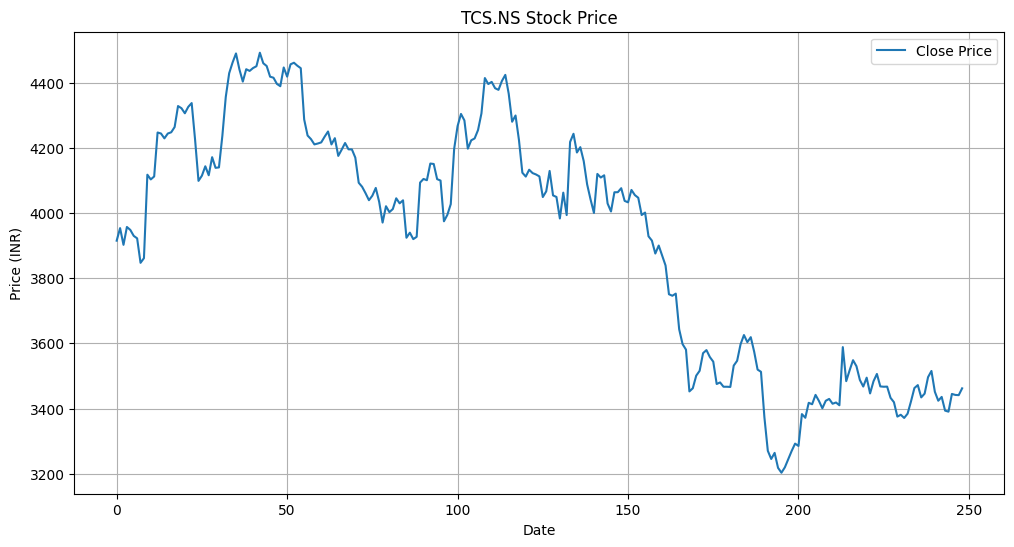

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Close Price')
plt.title(f"{ticker} Stock Price")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.legend()
plt.grid(True)
plt.show()


The stock's closing price shows an overall upward/downward trend over the selected time period. There are noticeable fluctuations that indicate periods of high volatility, which may be influenced by earnings reports, market news, or macroeconomic factors.

## Volume analysis

Shows high activity days

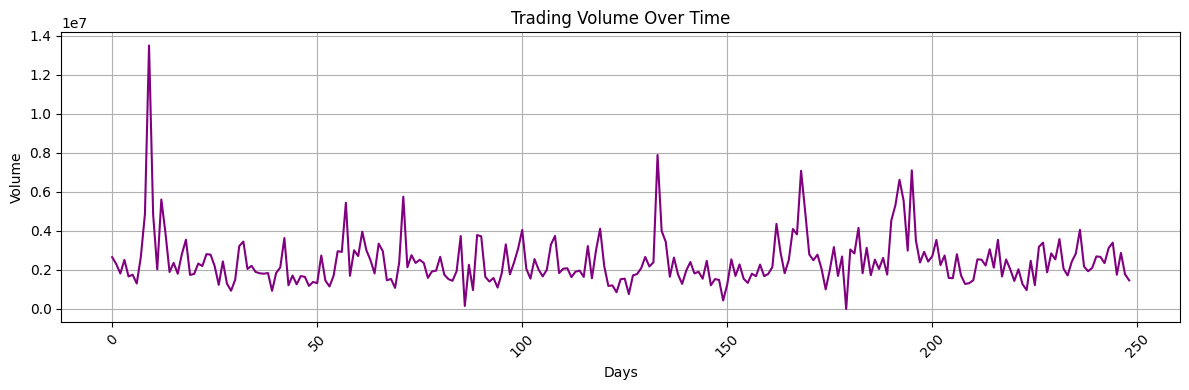

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(df['Volume'], color='purple') 
plt.title("Trading Volume Over Time")
plt.xlabel("Days")
plt.ylabel("Volume")
plt.grid()
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()


## Daily Returns

Shows distribution of daily return

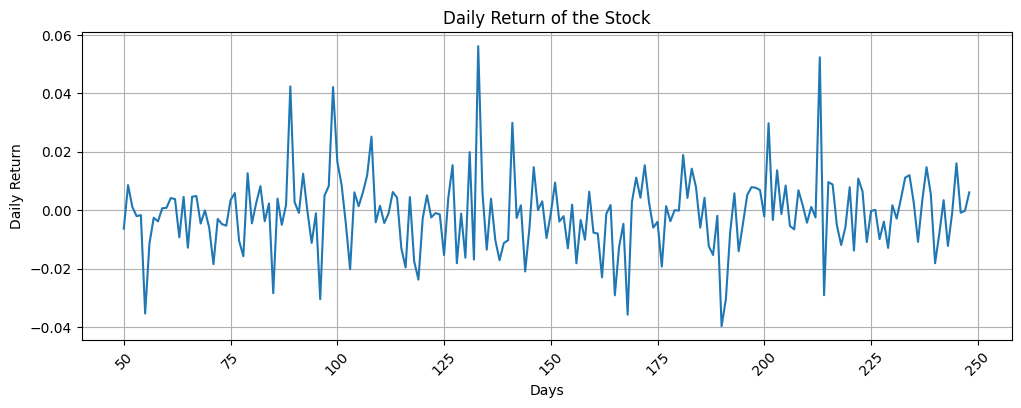

In [11]:
df_processed['Daily Return'] = df_processed['Close'].pct_change()

plt.figure(figsize=(12, 4))
df_processed['Daily Return'].plot()
plt.title("Daily Return of the Stock")
plt.xlabel("Days")
plt.ylabel("Daily Return")
plt.xticks(rotation=45) 
plt.grid()
plt.show()


## Correlation Matrix

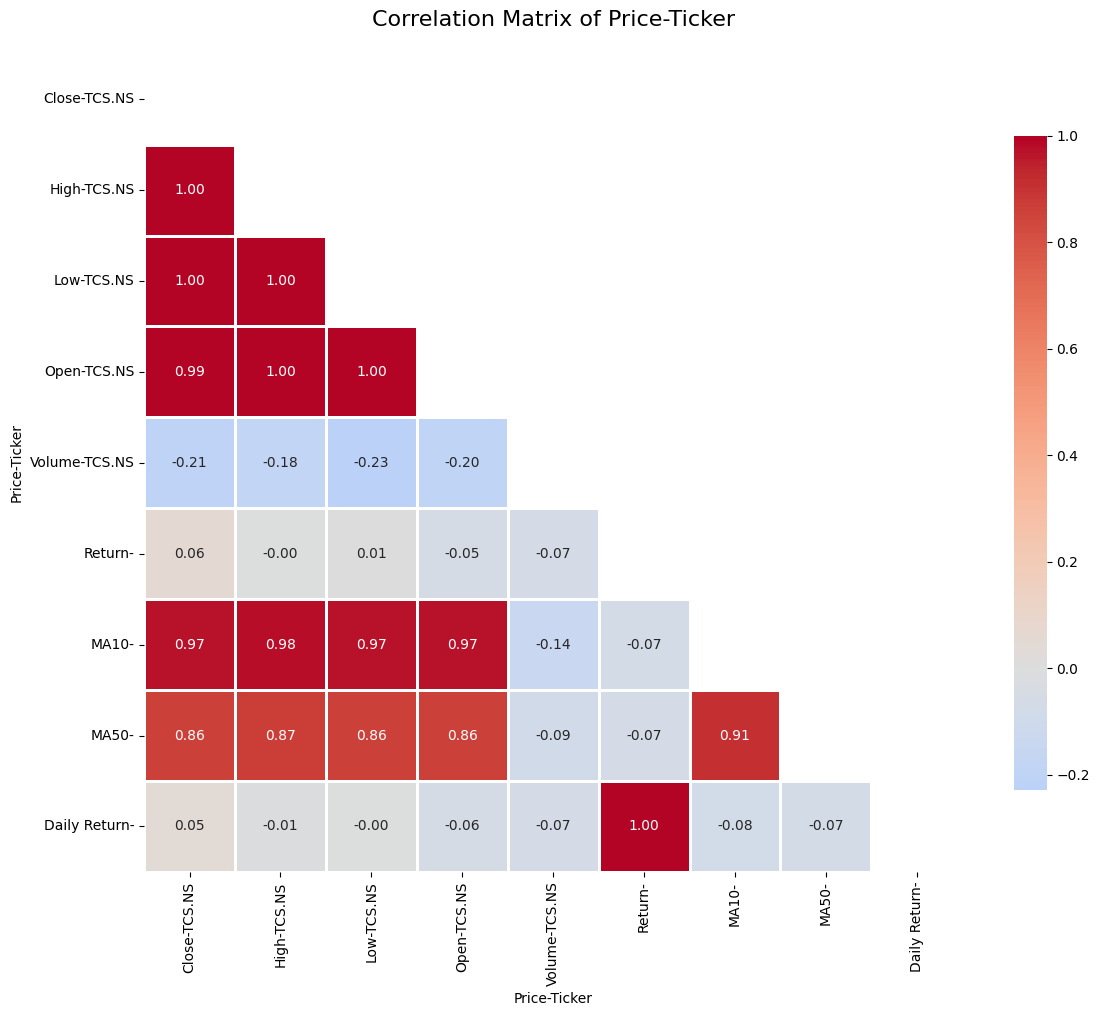

In [12]:
import seaborn as sns

columns=df_processed.columns.to_list()[2:]

corr_matrix = df_processed[columns].corr()

# Create a mask for the lower triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot the heatmap with the mask
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, linewidths=1,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Price-Ticker', fontsize=16, pad=20)
plt.tight_layout()
plt.show()


The heatmap shows that features like MA10 and MA50 are highly correlated with the closing price, which validates their inclusion as predictive variables. However, high correlation between features (e.g., MA10 vs MA50) might introduce redundancy, which should be considered when choosing input features.

##  Train a Simple Model


### Model Selection - Linear Regression

Linear Regression is a supervised machine learning algorithm that finds the best linear relationship between the input variables (features) and the output variable (target). It's simple, interpretable, and often a good baseline for time-series predictions.

We train the model using the training portion of the dataset and then predict on the test portion.



### Model Evaluation

To evaluate the model's performance, we use:
- **Mean Squared Error (MSE)**: Measures the average of the squares of the errors. Lower values indicate better performance.
- **Visualization**: Plotting actual vs. predicted values gives insight into how closely the model follows real trends.


### Limitations

While linear regression provides a good starting point, it's limited in modeling non-linear patterns and temporal dependencies.

In [13]:


def train_model(df, target_col='Close', save_path='models/linear_regression.joblib'):
    X = df[['MA10', 'MA50', 'Return']]
    y = df[target_col]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)

    joblib.dump(model, save_path)
    print(f"Model saved to {save_path}")

os.makedirs("models",exist_ok=True)
train_model(df_processed)

Model saved to models/linear_regression.joblib


## Making Predictions

In [14]:
def predict(df: pd.DataFrame, model_path='models/linear_regression.joblib'):
    model = joblib.load(model_path)
    X = df[['MA10', 'MA50', 'Return']]
    y_true = df['Close']
    y_pred = model.predict(X)
    mse = mean_squared_error(y_true, y_pred)
    print(f"Mean Squared Error: {mse:.4f}")
    return y_pred


def check_trade_signal(df: pd.DataFrame) -> str:
    """
    Rule-based trading signal:
    - BUY if MA10 crosses above MA50 (bullish crossover)
    - SELL if MA10 crosses below MA50 (bearish crossover)
    - HOLD otherwise
    """
    ma10_now = df['MA10'].iloc[-1]
    ma50_now = df['MA50'].iloc[-1]
    ma10_prev = df['MA10'].iloc[-2]
    ma50_prev = df['MA50'].iloc[-2]

    if ma10_now > ma50_now and ma10_prev <= ma50_prev:
        return "BUY ✅ (Bullish crossover)"
    elif ma10_now < ma50_now and ma10_prev >= ma50_prev:
        return "SELL ❌ (Bearish crossover)"
    elif ma10_now > ma50_now:
        return "BUY (still above MA50)"
    elif ma10_now < ma50_now:
        return "SELL (still below MA50)"
    else:
        return "HOLD ⏸️"


# After predictions
def predict_with_signal(df: pd.DataFrame, model_path='models/linear_regression.joblib'):
    predictions = predict(df, model_path)
    signal = check_trade_signal(df)
    # print(f"Trade Signal: {signal}")
    return predictions, signal

os.makedirs("reports",exist_ok=True)
predictions, signal = predict_with_signal(df_processed)
df_processed["Predicted_Close"] = predictions
df_processed.to_csv(f"reports/{ticker.replace('.', '_')}_with_predictions.csv", index=False)
print(f"[RESULT] Trade Decision: {signal}")


df_processed.columns

Mean Squared Error: 5300.6439
[RESULT] Trade Decision: BUY (still above MA50)


MultiIndex([(          'index',       ''),
            (           'Date',       ''),
            (          'Close', 'TCS.NS'),
            (           'High', 'TCS.NS'),
            (            'Low', 'TCS.NS'),
            (           'Open', 'TCS.NS'),
            (         'Volume', 'TCS.NS'),
            (         'Return',       ''),
            (           'MA10',       ''),
            (           'MA50',       ''),
            (   'Daily Return',       ''),
            ('Predicted_Close',       '')],
           names=['Price', 'Ticker'])

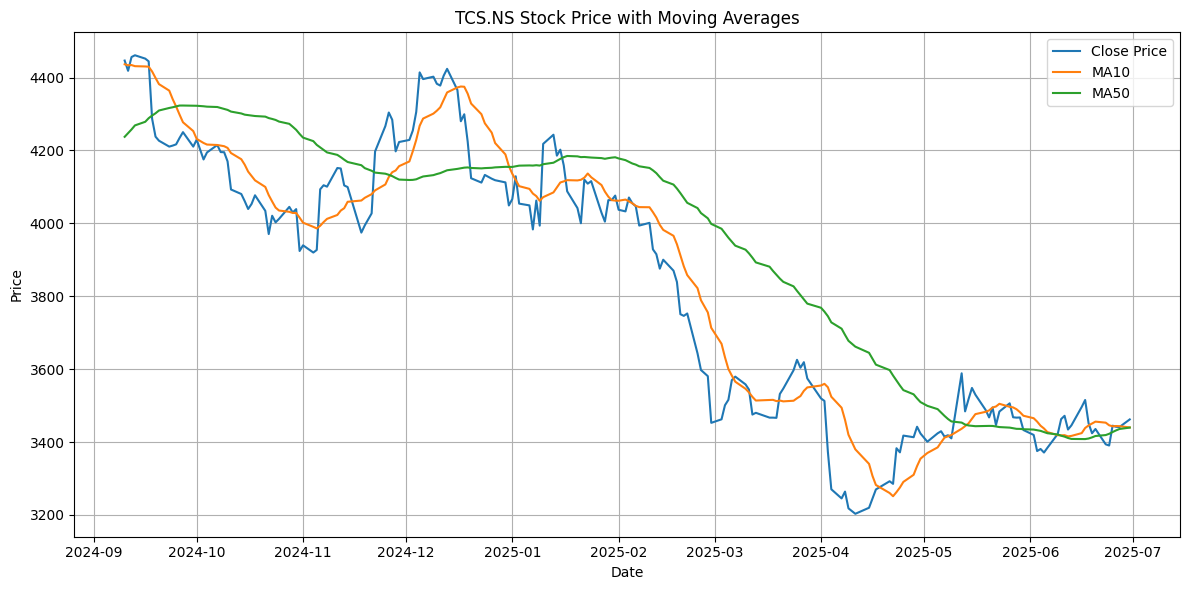

In [15]:
def plot_stock_prices(df, ticker):
    plt.figure(figsize=(12, 6))
    plt.plot(df['Date'], df['Close'], label='Close Price')
    plt.plot(df['Date'], df['MA10'], label='MA10')
    plt.plot(df['Date'], df['MA50'], label='MA50')
    plt.title(f'{ticker} Stock Price with Moving Averages')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('reports/figures/price_plot.png')
    plt.show()


os.makedirs("reports/figures",exist_ok=True)
plot_stock_prices(df_processed,ticker)

The 10-day moving average reacts more quickly to price changes than the 50-day moving average. Crossovers between the two (e.g., MA10 crossing above MA50) may indicate potential buy signals, while downward crossovers may suggest selling points. The gap between them can also reflect momentum strength.

##  Compare Actual vs Predicted

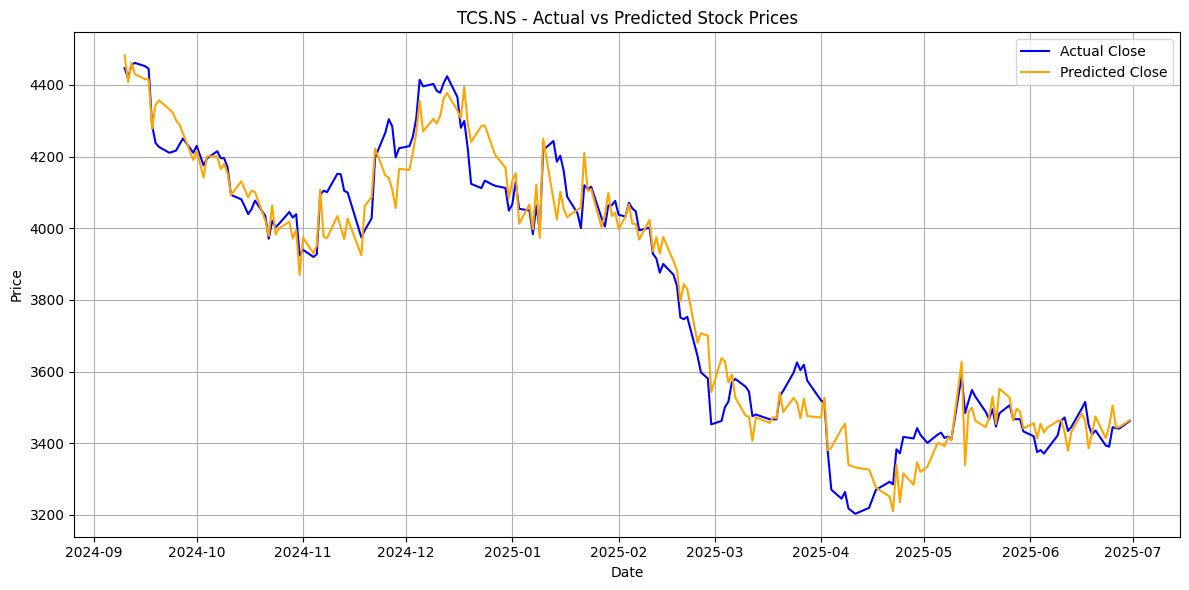

[METRICS] MAE: 56.93
[METRICS] MSE: 5300.64
[METRICS] RMSE: 72.81


In [16]:
from sklearn.metrics import mean_absolute_error


def compare_actual_vs_predicted(df, ticker):

    # Determine x-axis
    x_axis = df['Date']

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(x_axis, df['Close'], label='Actual Close', color='blue')
    plt.plot(x_axis, df['Predicted_Close'], label='Predicted Close', color='orange')
    plt.title(f'{ticker} - Actual vs Predicted Stock Prices')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'reports/figures/{ticker.replace(".", "_")}_actual_vs_predicted.png')
    plt.show()

    # Calculate metrics
    mae = mean_absolute_error(df['Close'], df['Predicted_Close'])
    mse = mean_squared_error(df['Close'], df['Predicted_Close'])
    rmse = np.sqrt(mse)

    print(f"[METRICS] MAE: {mae:.2f}")
    print(f"[METRICS] MSE: {mse:.2f}")
    print(f"[METRICS] RMSE: {rmse:.2f}")

compare_actual_vs_predicted(df_processed,ticker)

The predicted prices closely follow the actual stock price trend, indicating that the model has learned general patterns in the data. However, some deviations show that the model may not capture sudden market movements or non-linear behavior—typical limitations of linear regression.

## Next Day Prediction

In [ ]:

import numpy as np
import pandas as pd
import joblib

def forcast_next_5_days(last_60_df: pd.DataFrame, model_path: str) -> pd.DataFrame:
    
    model = joblib.load(model_path)

 
    if isinstance(last_60_df.columns, pd.MultiIndex):
        last_60_df.columns = ['_'.join(col).strip() for col in last_60_df.columns]


    close_col = next((col for col in last_60_df.columns if 'Close' in col), None)
    if close_col is None:
        raise ValueError("No 'Close' column found.")
    
    base_close = last_60_df[close_col].tolist()


    predicted_close_list = []

    for day in range(5):
       
        working_close = base_close + predicted_close_list
        temp_df = pd.DataFrame({'Close': working_close})

    
        temp_df['MA10'] = temp_df['Close'].rolling(window=10).mean()
        temp_df['MA50'] = temp_df['Close'].rolling(window=50).mean()
        temp_df['Return'] = temp_df['Close'].pct_change()

       
        last_row = temp_df.iloc[-1]

        try:
            ma10 = float(last_row['MA10'])
            ma50 = float(last_row['MA50'])
            ret = float(last_row['Return'])
        except (TypeError, ValueError):
            print(f"[WARN] Day {day+1}: Invalid feature values. Skipping.")
            predicted_close_list.append(np.nan)
            continue

        if any(pd.isna([ma10, ma50, ret])):
            print(f"[WARN] Day {day+1}: NaN in features. Skipping.")
            predicted_close_list.append(np.nan)
            continue

        feature_row = np.array([[ma10, ma50, ret]])
        predicted_close = float(model.predict(feature_row).item())
        print(f"[DEBUG] Day {day+1}: Predicted Close = {predicted_close}")
        predicted_close_list.append(predicted_close)

    return pd.DataFrame({
        'Day': range(1, 6),
        'Predicted_Close': predicted_close_list
    })




In [19]:
print("[INFO] Forecasting next 5 days...")

last_60 = df.tail(60).copy()
future_preds = forcast_next_5_days(last_60, "models/linear_regression.joblib")
print(f"[RESULT] Future Predictions:\n{future_preds}")

[INFO] Forecasting next 5 days...
[DEBUG] Day 1: Predicted Close = 3464.0975648804774
[DEBUG] Day 2: Predicted Close = 3438.1442446989913
[DEBUG] Day 3: Predicted Close = 3406.7986439133592
[DEBUG] Day 4: Predicted Close = 3398.9347660689355
[DEBUG] Day 5: Predicted Close = 3419.6693392365028
[RESULT] Future Predictions:
   Day  Predicted_Close
0    1      3464.097565
1    2      3438.144245
2    3      3406.798644
3    4      3398.934766
4    5      3419.669339


## Conclusions

In this stock prediction project, we demonstrated how to apply a basic machine learning model—Linear Regression—to forecast the next day's closing price of a stock. Using data fetched via the yfinance library, we:

- Performed exploratory data analysis (EDA) to understand stock behavior.

- Engineered useful features such as moving averages and daily returns.

- Trained and tested a Linear Regression model.

- Visualized and evaluated the model’s performance using MSE and comparison plots.

While the model provides a starting point, it’s important to note the limitations of linear models for stock prediction. Stock prices are influenced by numerous unpredictable factors like news, sentiment, and global events.